In [1]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ #                         
#     Maurice F. Huguenin, mhuguenin-virchaux@geomar.de, 25th June 2026       #                                                
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ #
# % preamble ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ #                         
base = '/g/data/e14/mv7494/access-om2/archive/025deg_jra55_iaf/'
save = '/gxfs_home/geomar/smomw723/EddiesHC_figures/'

import xarray as xr # for working with labelled multi-dimensional arrays                                                                
import numpy as np # for numerical operations                                                           
import string # for subplot annotation
import matplotlib.pyplot as plt # for matlab-like plotting                                              
from matplotlib.patches import Rectangle # for shaded rectangle
import cartopy.crs as ccrs # for maps     
from matplotlib import gridspec
import matplotlib as mpl
#from cdo import *
#cdo = Cdo()
import os
import sys
import scipy
import warnings
import cmocean as cm
#from wrf import to_np # conversion to arrays required for arrows on maps    
import tarfile as tf
import io
from scipy.stats import linregress
from datetime import datetime

import matplotlib.patheffects as PathEffects
warnings.filterwarnings('ignore') # suppress warnings
from matplotlib import ticker
import nc_time_axis
import time
import cftime
import cartopy.mpl.ticker as cticker
import string # for subplot annotation
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

rotblau = [[0.4 , 0.  , 0.12], [0.47, 0.02, 0.13], [0.62, 0.07, 0.16], [0.66, 0.16, 0.2],
           [0.8 , 0.3 , 0.27], [0.87, 0.44, 0.35], [0.93, 0.58, 0.45], [0.96, 0.7 , 0.58], 
           [0.98, 0.8 , 0.71], [0.98, 0.94, 0.92], [0.93, 0.95, 0.96], [0.85, 0.91, 0.95],
           [0.76, 0.87, 0.93], [0.64, 0.8 , 0.89], [0.49, 0.72, 0.84], [0.34, 0.62, 0.79], 
           [0.23, 0.53, 0.74], [0.16, 0.44, 0.7] , [0.1 ,0.35, 0.6], [0.05, 0.24, 0.45], [0.02, 0.19, 0.38]]

/gxfs_home/geomar/smomw723/miniforge3/envs/py3_std/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


OHC = $\int_0^{360°E}\int_{90°S}^{90°N}\int_{-5875m}^{0m}\rho_0C_p\theta dV$

In [2]:
# rho_0 = 1025.022            # global ocean reference density of sea water used in FOCI-MOPS [kg m^{-3}]
# C_p   = 3992.10322329649    # global ocean average specific heat capacity [J kg^{-1} K^{-1}]
# \Theta [votemper]           # potential temperature of sea water [K]
# dV [area_t * e3t]           # grid cell volume, area * time-dependent grid cell height [m^{3}]

### Loading in PI-CTRL and historical OHC

CPU times: user 1.88 s, sys: 135 ms, total: 2.02 s
Wall time: 5.43 s


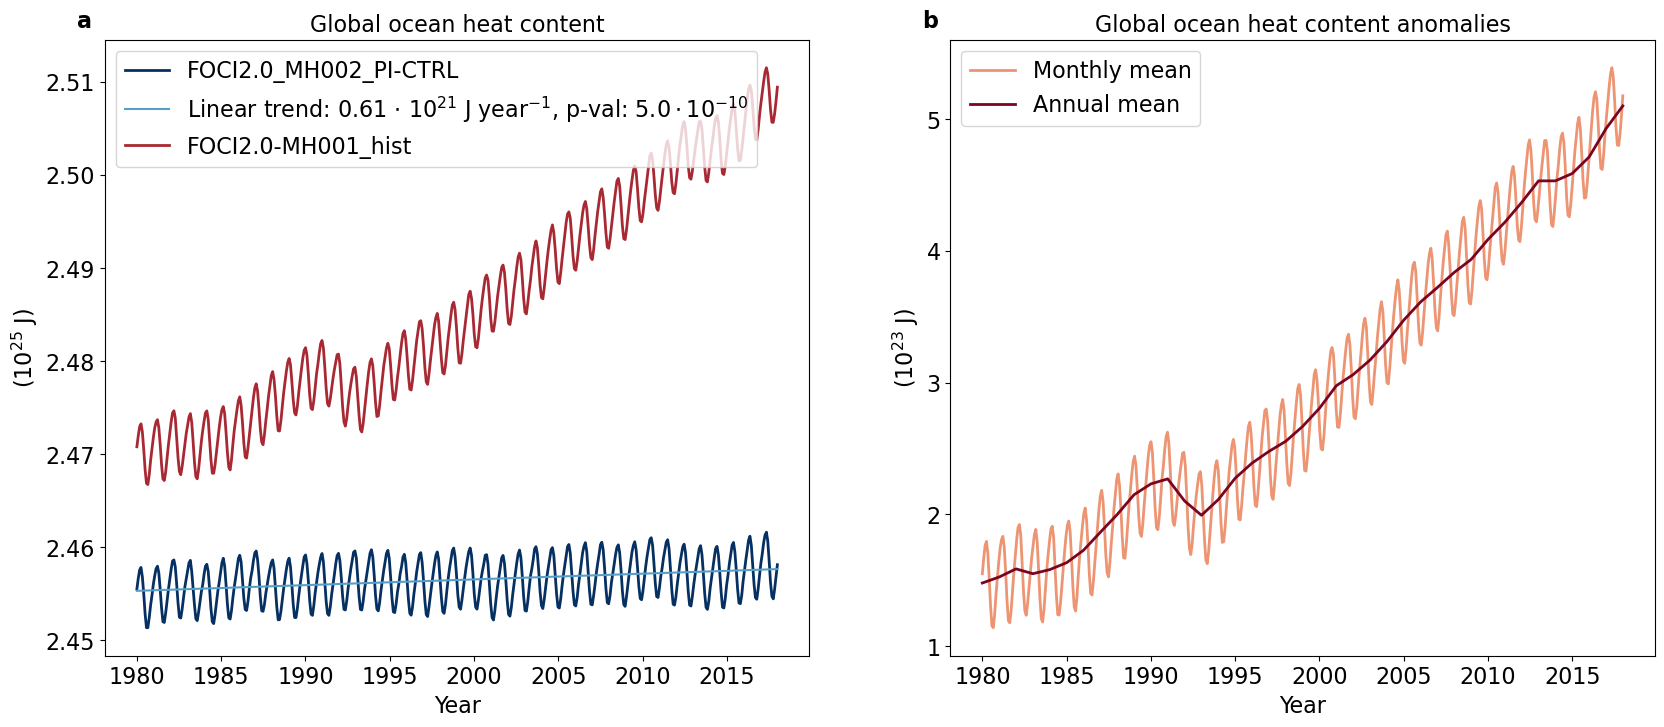

In [3]:
%%time
exp_names  = ['FOCI2.0_MH002_PI-CTRL_ESM_1979CC103_incl-OHC-DIC-budgets', 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC']
exp_labels = ['FOCI2.0_MH002_PI-CTRL', 'FOCI2.0-MH001_hist']
OHC_PICtrl = xr.open_mfdataset('/gxfs_work/geomar/smomw723/EddiesHC_data/'+exp_names[0]+'_ts_OHC_*.nc').OHC_manual 
OHC_hist   = xr.open_mfdataset('/gxfs_work/geomar/smomw723/EddiesHC_data/'+exp_names[1]+'_ts_OHC_*.nc').OHC_manual 


# calculating linear trend in the PI-CTRL
time = np.linspace(1980,2018,len(OHC_PICtrl.time_counter)) # monthly time series
time2 = np.linspace(1980,2018,int(len(OHC_PICtrl.time_counter)/12)) # annual time series

result = linregress(time, OHC_PICtrl)
# print("slope:", result.slope); print("p-value:", result.pvalue); print("R²:", result.rvalue**2)
mantissa, exponent = f"{result.pvalue:.1e}".split("e") # round to 1 digit & convert for better writing in latex-style, i.e., 6.5 * 10^{-274}
z = np.polyfit(time, OHC_PICtrl, 1); poly1 = np.poly1d(z)

plt.figure(figsize=(20,8)) # initialise figure
# first subplot
# ----------------------------------------------------------------------------------------
ax1 = plt.subplot(1,2,1)
plt.plot(time, OHC_PICtrl/1e25, label=exp_labels[0], linewidth=2, color=rotblau[20])
plt.plot(time, poly1(time)/1e25, label='Linear trend: '+ 
         str(np.round(poly1[1]/1e21,2)) + r' $\cdot$ 10$^{21}$ J year$^{-1}$, p-val: ' +
         rf"${mantissa} \cdot 10^{{{int(exponent)}}}$", color=rotblau[15])
plt.plot(time, OHC_hist/1e25, label=exp_labels[1], linewidth=2, color=rotblau[3])

plt.xticks(fontsize=16); plt.yticks(fontsize=16)
plt.ylabel('(10$^{25}$ J)', fontsize=16); plt.xlabel('Year', fontsize=16)
plt.title('Global ocean heat content', fontsize=16)  
plt.legend(fontsize=16)

ax1.text(-.04, 1.02 ,string.ascii_lowercase[0], transform=ax1.transAxes, size=16, weight='bold') # bold letter a at the top

# second subplot
# ----------------------------------------------------------------------------------------
ax1 = plt.subplot(1,2,2)
plt.plot(time, (OHC_hist - poly1(time))/1e23, label='Monthly mean', linewidth=2, color=rotblau[6]) # divide by 1e23 and write this into ylabel
plt.plot(time2, (OHC_hist - poly1(time)).groupby('time_counter.year').mean()/1e23, label='Annual mean', linewidth=2, color=rotblau[1])

plt.xticks(fontsize=16); plt.yticks(fontsize=16)
plt.ylabel('(10$^{23}$ J)', fontsize=16); plt.xlabel('Year', fontsize=16)
plt.title('Global ocean heat content anomalies', fontsize=16)  
plt.legend(fontsize=16)
ax1.text(-.04, 1.02 ,string.ascii_lowercase[1], transform=ax1.transAxes, size=16, weight='bold') # bold letter a at the top

# --- saving as 300 dpi .PNG image in specified folder ---------------------------------------------- #
plt.savefig(save + 'global_heat_content_time_series_1980-2018', dpi=300, facecolor='w',               #
            edgecolor='w', orientation='landscape', format=None, transparent=False,                   # 
            bbox_inches='tight', pad_inches=0.1, metadata=None)                                       #
# --- end of script --------------------------------------------------------------------------------- # 
# Wall time: 845 ms

### Next, spatial map of SST anomalies

FOCI2.0_MH002_PI-CTRL
FOCI2.0-MH001_hist
CPU times: user 14 s, sys: 1.94 s, total: 16 s
Wall time: 30.8 s


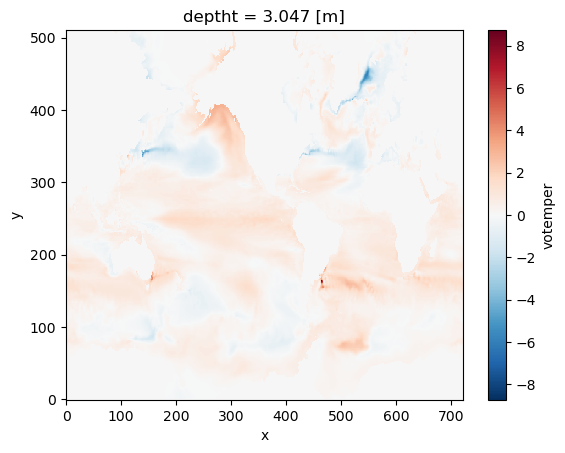

In [46]:
%%time
#plt.figure(figsize=(12,4))
archive   = '/gxfs_work/geomar/smomw723/'

exp_names = ['FOCI2.0_MH002_PI-CTRL_ESM_1979CC103_incl-OHC-DIC-budgets', 'FOCI2.00.0-MH001_hist_ESM_incl_OHC_DIC']
exp_labels = ['FOCI2.0_MH002_PI-CTRL', 'FOCI2.0-MH001_hist']

vars = ['votemper']
fn   = ['_grid_T']
freq = ['_1m_', '_1y_']

for f in range(2): # loop through both the pre-industrial control simulation and the historical simulation
    print(exp_labels[f])
    # load the netcdf file from the archive folder and select the votemper variable
    votemper = xr.open_mfdataset(archive + exp_names[f] + '/outdata/nemo/' + exp_names[f] + freq[0] + '*_grid_T.nc', chunks={'time': '200MB'}).votemper # grid cell pot. temp.
    sst = votemper[:24,0,:,:].mean('time_counter').load() # select mean 1980-1981 SST anomalies and load into memory

    if f == 0: sst_CTRL = sst
    if f == 1: sst_hist = sst
sst_anom = sst_hist - sst_CTRL # anomalies by just removing the PI-CTRL - not yet removed linear trend in PI-CTRL as above
sst_anom.plot()
# Wall time: 30.8 s

### Transform coordinates for plotting

In [38]:
%%time
# detect coordinate names
lat_name = [c for c in sst.coords if "lat" in c.lower()][0]
lon_name = [c for c in sst.coords if "lon" in c.lower()][0]

lat = sst[lat_name].values
lon = sst[lon_name].values

# 2D mesh or already lat2D/lon2D
if lat.ndim == 1 and lon.ndim == 1:
    lon2d, lat2d = np.meshgrid(lon, lat)
else:
    lon2d, lat2d = lon, lat

z = np.squeeze(sst.values)   # ensure 2-D

# convert lon to -180..180 for Cartopy
if np.nanmax(lon2d) > 180:
    lon2d = ((lon2d + 180) % 360) - 180
    
ticks = np.linspace(0,3,21) # ticks for colour bar

CPU times: user 688 μs, sys: 0 ns, total: 688 μs
Wall time: 486 μs


### Plotting routine

CPU times: user 9.61 s, sys: 188 ms, total: 9.8 s
Wall time: 9.89 s


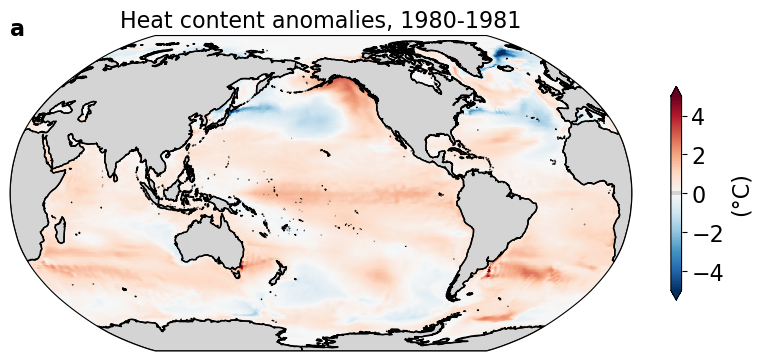

In [54]:
%%time
fs = 16
level_steps = [-5,5] # data/colour bar limits

# Create figure and map
fig = plt.figure(figsize=(16,9),tight_layout=True,facecolor='w',edgecolor='k')
gs = gridspec.GridSpec(2, 2, width_ratios = [1,1]) 
ax1 = plt.subplot(gs[0,0], projection=ccrs.Robinson(central_longitude=200))

# Plot the data
p1 = ax1.pcolormesh(lon, lat, sst_anom, transform=ccrs.PlateCarree(), vmin=level_steps[0], vmax=level_steps[1], cmap='RdBu_r')
# contour does not work; why?
#p11 = ax1.contour(lon, lat, sst, levels=[0], linewidths=3, colors='g', transform=ccrs.PlateCarree())

# Add land, coastlines, etc.
ax1.coastlines(resolution = '50m', linewidth=1) # add coast lines
ax1.add_feature(cfeature.LAND, edgecolor = 'black', facecolor = [.83, .83, .83], zorder = 1)
plt.title('Heat content anomalies, 1980-1981', fontsize=fs)

# add colour bar
cb = plt.colorbar(p1, shrink=.5, orientation='vertical', extend='both'); 
cb.set_label(label='(°C)', size=fs)
cb.ax.tick_params(labelsize=fs); tick_locator = ticker.MaxNLocator(nbins=5)
cb.locator = tick_locator;cb.update_ticks()  
cb.add_lines(p11) # add contours to colour bar

ax1.text(0, 1, string.ascii_lowercase[0], transform=ax1.transAxes, size=16, weight='bold') # bold panel letter at the top left

# --- saving as 300 dpi .PNG image in specified folder --------------------- #
plt.savefig(save + 'sst_Robinson_1980-1981', 
            dpi=300, facecolor='w',                                          #
            edgecolor='w', orientation='landscape',                          #
            format=None, transparent=False, bbox_inches='tight',             #
            pad_inches=0.1, metadata=None)                                   #
# --- end of script -------------------------------------------------------- # 
# Wall time: 9.89 s